
===== MODEL COMPARISON =====
                 Model  Accuracy
2        Random Forest  0.815642
0  Logistic Regression  0.804469
1                  SVM  0.782123

===== BEST MODEL =====
Random Forest with accuracy 81.56%


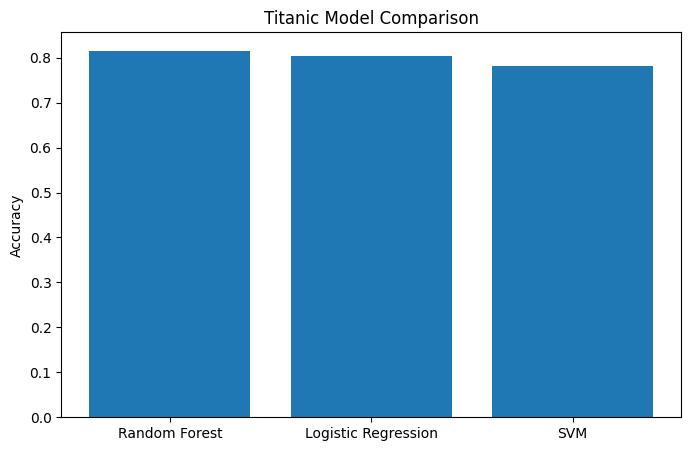

<Figure size 640x480 with 0 Axes>


===== LOGISTIC REGRESSION =====
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       105
           1       0.81      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179


===== SVM =====
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       105
           1       0.76      0.69      0.72        74

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179


===== RANDOM FOREST =====
              precision    recall  f1-score   support

           0       0.81      0.90      0.85       105
           1       0.84      0.69      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       1

In [1]:
import pandas as pd

# =========================
# LOAD DATA
# =========================

df = pd.read_csv("train.csv")

# =========================
# DATA CLEANING
# =========================

df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(
    df["Embarked"].mode()[0]
)

# =========================
# ENCODE CATEGORICAL DATA
# =========================

df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

df["Embarked"] = df["Embarked"].map({
    "S": 0,
    "C": 1,
    "Q": 2
})

# =========================
# FEATURE SELECTION
# =========================

features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X = df[features]
y = df["Survived"]

# =========================
# TRAIN TEST SPLIT
# =========================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=21
)

# =========================
# FEATURE SCALING
# =========================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# LOGISTIC REGRESSION
# =========================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

lr_acc = accuracy_score(y_test, lr_pred)

# =========================
# SVM
# =========================

from sklearn.svm import SVC

svm = SVC(
    kernel="linear",
    random_state=21
)

svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_test_scaled)

svm_acc = accuracy_score(y_test, svm_pred)

# =========================
# RANDOM FOREST
# =========================

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=21
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

# =========================
# RESULTS TABLE
# =========================

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest"
    ],
    "Accuracy": [
        lr_acc,
        svm_acc,
        rf_acc
    ]
})

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n===== MODEL COMPARISON =====")
print(results)

# =========================
# BEST MODEL
# =========================

best_model = results.iloc[0]

print("\n===== BEST MODEL =====")
print(
    f"{best_model['Model']} "
    f"with accuracy "
    f"{best_model['Accuracy']*100:.2f}%"
)

# =========================
# BAR CHART
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Titanic Model Comparison")
plt.ylabel("Accuracy")

plt.show()

plt.savefig("feature_importance.png")
plt.show()

from sklearn.metrics import classification_report

print("\n===== LOGISTIC REGRESSION =====")

print(
    classification_report(
        y_test,
        lr_pred
    )
)

print("\n===== SVM =====")

print(
    classification_report(
        y_test,
        svm_pred
    )
)

print("\n===== RANDOM FOREST =====")

print(
    classification_report(
        y_test,
        rf_pred
    )
)

print("\n===== LOGISTIC REGRESSION =====")

print(
    classification_report(
        y_test,
        lr_pred
    )
)

print("\n===== SVM =====")

print(
    classification_report(
        y_test,
        svm_pred
    )
)

print("\n===== RANDOM FOREST =====")

print(
    classification_report(
        y_test,
        rf_pred
    )
)

Three classification models were evaluated on the Titanic dataset.

Random Forest achieved the highest accuracy (81.56%), followed by Logistic Regression (80.45%) and SVM (78.21%).

The small gap between Random Forest and Logistic Regression suggests that the dataset contains reasonably strong linear patterns, while Random Forest benefited from its ability to model feature interactions and non-linear relationships.